### VWAMP signals analysis:

Daily VWAP analysis

In [1]:
import os
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
from qf.strategies import DATA_DIR

In [3]:
prices_file = os.path.join(DATA_DIR, 'prices.csv')
prices_df = pd.read_csv(prices_file, parse_dates=['date'], index_col='date')
display(prices_df)

,ticker,open,high,low,close,volume
date,,,,,,
2020-10-27,AAPL,115.119074,116.903326,114.172128,116.225510,92276800
2020-10-28,AAPL,114.680491,115.059267,110.743172,110.842850,143937800
2020-10-29,AAPL,112.009093,116.554445,111.839634,114.949615,146129200
2020-10-30,AAPL,110.703292,111.630305,107.374023,108.510361,190272600
2020-11-02,AAPL,108.759566,110.324523,106.975314,108.420654,122866900
...,...,...,...,...,...,...
2021-04-20,ADBE,515.289978,517.289978,510.600006,514.210022,1677500
2021-04-21,ADBE,515.020020,515.479980,509.549988,512.340027,1678100
2021-04-22,ADBE,508.079987,512.770020,504.059998,507.290009,2084600


In [4]:
f"Available tickers: {list(prices_df.ticker.unique())}"

"Available tickers: ['AAPL', 'MSFT', 'AMZN', 'GOOG', 'FB', 'WMT', 'JPM', 'TSLA', 'NFLX', 'ADBE']"

In [5]:
ticker = 'AAPL'

In [7]:
df = (prices_df.loc[prices_df['ticker'] == ticker]).copy()

### Single Day VWAP

In [10]:
s = pd.Series([1,2,3])

In [ ]:
# Robust VWAP/rolling avg calculation with checks and per-ticker handling
required = {'high', 'low', 'close', 'volume'}
missing = list(required - set(df.columns))
if missing:
    raise KeyError(f"DataFrame is missing required columns: {missing}")

# Ensure numeric types (coerce errors to NaN so calculations don't crash)
for col in required:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Average price and rolling average (use min_periods=1 to avoid all-NaN windows)
df['avg_price'] = (df['high'] + df['low'] + df['close']) / 3
df['avg_price_rolling'] = df['avg_price'].rolling(window=5, min_periods=1).mean()

# VWAMP: volume-weighted average price cumulative, computed per ticker if present
def _vwamp_from_group(g):
    pv = (g['volume'] * g['avg_price']).fillna(0)       # price * volume
    vol = g['volume'].fillna(0).astype(float)          # ensure float for division
    pv_cum = pv.cumsum()
    vol_cum = vol.cumsum()
    # avoid division by zero by replacing zero cumulative volume with NaN
    vw = pv_cum / vol_cum.replace({0: np.nan})
    return vw

if 'ticker' in df.columns:
    # group_keys=False preserves original index alignment
    df['vwamp'] = df.groupby('ticker', group_keys=False).apply(_vwamp_from_group)
else:
    df['vwamp'] = _vwamp_from_group(df)

# Optional: clean up any infinite values and keep NaNs for further handling
df['vwamp'].replace([np.inf, -np.inf], np.nan, inplace=True)

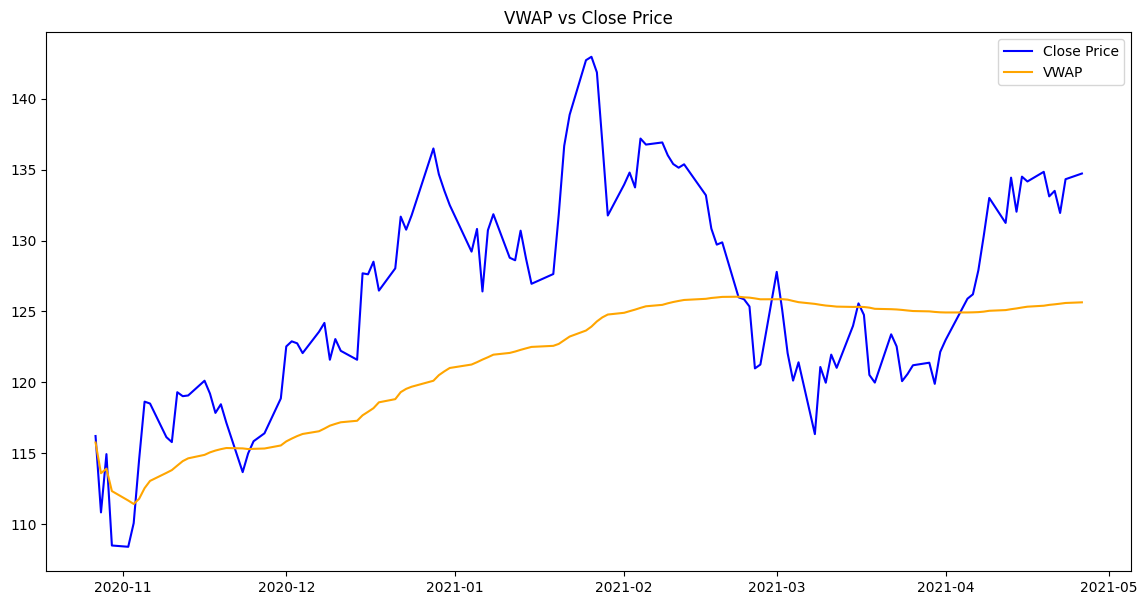

In [58]:
# Plot the VWAP against the closing prices
plt.figure(figsize=(14, 7))
plt.plot(df['close'], label='Close Price', color='blue')
plt.plot(df['vwamp'], label='VWAP', color='orange')
plt.title('VWAP vs Close Price')
plt.legend()
plt.show()

### Trading Strategy Based on VWAP

Now, let’s build a simple VWAP-based trading strategy:

* Buy when the price is below the VWAP (assuming the stock is undervalued).
* Sell when the price is above the VWAP (assuming the stock is overvalued).

In [60]:
# Define a column for buy/sell signals
df['signal'] = np.where(df['close'] < df['vwamp'], 'buy', 'sell')

# Simulating a simple strategy where you buy when the signal is 'Buy' and sell when the signal is 'Sell'
df['position'] = np.where(df['signal'] == 'buy', 1, -1)

# Calculate daily returns
df['returns'] = df['close'].pct_change()

# Strategy returns: Position * Market Returns
df['strategy_returns'] = df['position'].shift(1) * df['returns']

# Plot cumulative returns
df['cumulative_strategy_returns'] = (1 + df['strategy_returns']).cumprod()

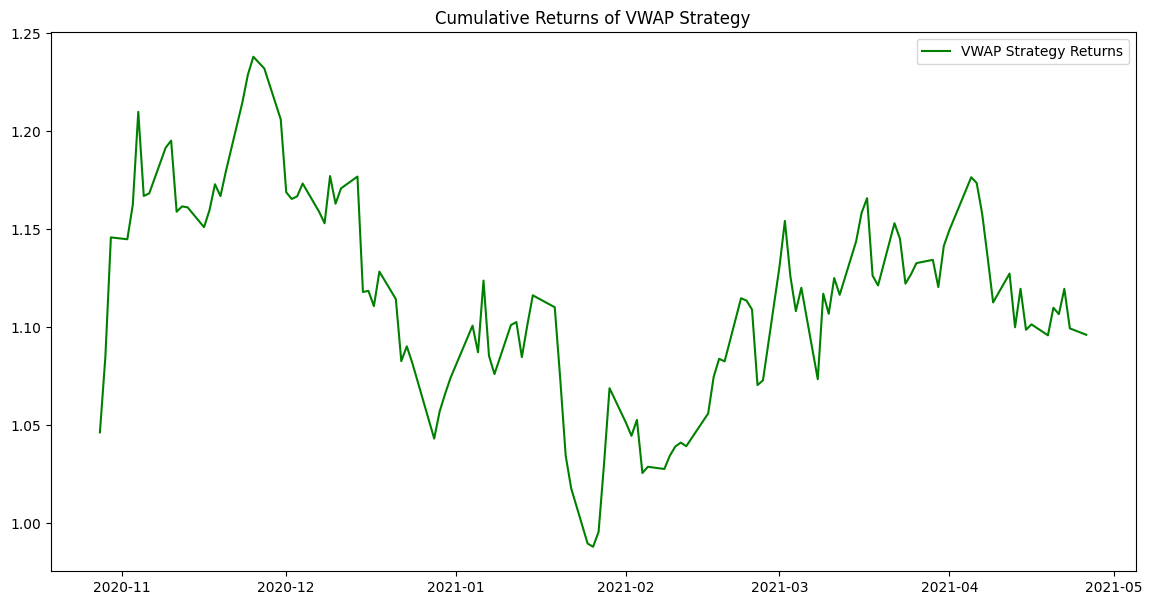

In [61]:
plt.figure(figsize=(14, 7))
plt.plot(df['cumulative_strategy_returns'], label='VWAP Strategy Returns', color='green')
plt.title('Cumulative Returns of VWAP Strategy')
plt.legend()
plt.show()

In [62]:
df = pd.DataFrame(np.arange(10).reshape(5, 2), columns=['a', 'b'])
df2 = df[['a', 'b']].apply(lambda ser: pd.Series({
    'mean': ser.mean(),
    'std': ser.std(ddof=0),
    'max': np.amax(ser.to_numpy())
}), axis=1)
df2 = pd.concat((df, df2), axis=1)

display(df2)

,a,b,mean,std,max
0,0,1,0.5,0.5,1.0
1,2,3,2.5,0.5,3.0
2,4,5,4.5,0.5,5.0
3,6,7,6.5,0.5,7.0
4,8,9,8.5,0.5,9.0
